# Dependency Parsing – Minh họa bằng thư viện (spaCy & Stanza)

## 1. Cài đặt thư viện và tải mô hình

In [3]:
!pip install spacy stanza networkx matplotlib pandas -q
!python -m spacy download en_core_web_sm
!stanza.download('en')

'pip' is not recognized as an internal or external command,
operable program or batch file.


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------- -------------------------------- 2.4/12.8 MB 25.4 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 51.1 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


'stanza.download' is not recognized as an internal or external command,
operable program or batch file.


## 2. Khởi tạo pipeline

In [4]:
import spacy
import stanza
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# spaCy – transition-based
nlp_spacy = spacy.load("en_core_web_sm")

# Stanza – graph-based
nlp_stanza = stanza.Pipeline(lang='en', processors='tokenize,pos,lemma,depparse', tokenize_pretokenized=False)

2026-05-19 00:23:13 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-05-19 00:23:13 INFO: Downloaded file to C:\Users\ADMIN\AppData\Local\StanfordNLP\stanza\Cache\1.12.0\resources\resources.json
2026-05-19 00:23:13 WARNING: Language en package default expects mwt, which has been added
2026-05-19 00:23:14 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |
| depparse  | combined_charlm   |

2026-05-19 00:23:14 INFO: Using device: cpu
2026-05-19 00:23:14 INFO: Loading: tokenize
2026-05-19 00:23:16 INFO: Loading: mwt
2026-05-19 00:23:16 INFO: Loading: pos
2026-05-19 00:23:17 INFO: Loading: lemma
2026-05-19 00:23:18 INFO: Loading: depparse
2026-05-19 00:23:18 INFO: Done loading processors!


## 3. Hàm hiển thị cây dependency
Dùng `networkx` để vẽ đồ thị có hướng từ các quan hệ head → dependent.

In [6]:
def plot_dependency_tree(words, heads, deprel, title="Dependency Tree"):
    """
    words: list of strings, vị trí 0 là ROOT (nếu có)
    heads: list of int, head index (0-based, -1 cho ROOT)
    deprel: list of str, quan hệ dependency
    """
    G = nx.DiGraph()
    # Thêm các đỉnh
    for i, w in enumerate(words):
        G.add_node(i, label=w)
    # Thêm các cạnh
    for i, (h, r) in enumerate(zip(heads, deprel)):
        if h >= 0:
            G.add_edge(h, i, label=r)
    # Vẽ
    pos = nx.spring_layout(G, seed=42, k=2)
    labels = nx.get_node_attributes(G, 'label')
    edge_labels = nx.get_edge_attributes(G, 'label')
    plt.figure(figsize=(10, 6))
    nx.draw(G, pos, with_labels=True, labels=labels, node_size=2000, node_color='lightblue',
            font_size=10, arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
    plt.title(title)
    plt.axis('off')
    plt.show()

## 4. Phân tích một câu đơn giản với cả hai parser
Câu mẫu: *“I prefer the morning flight through Denver”* (trích trong sách).

In [7]:
sentence = "I prefer the morning flight through Denver"

# spaCy
doc_spacy = nlp_spacy(sentence)
print("spaCy (transition-based):")
for token in doc_spacy:
    print(f"{token.text:10} -> head: {token.head.text:10} ({token.dep_})")

# Stanza
doc_stanza = nlp_stanza(sentence)
print("\nStanza (graph-based):")
for sent in doc_stanza.sentences:
    for word in sent.words:
        head_word = sent.words[word.head-1].text if word.head > 0 else "ROOT"
        print(f"{word.text:10} -> head: {head_word:10} ({word.deprel})")

spaCy (transition-based):
I          -> head: prefer     (nsubj)
prefer     -> head: prefer     (ROOT)
the        -> head: flight     (det)
morning    -> head: flight     (compound)
flight     -> head: prefer     (dobj)
through    -> head: flight     (prep)
Denver     -> head: through    (pobj)

Stanza (graph-based):
I          -> head: prefer     (nsubj)
prefer     -> head: ROOT       (root)
the        -> head: flight     (det)
morning    -> head: flight     (compound)
flight     -> head: prefer     (obj)
through    -> head: Denver     (case)
Denver     -> head: flight     (nmod)


## 5. So sánh UAS / LAS trên một tập câu nhỏ
Chúng ta tự tạo một **gold standard** thủ công dựa trên kiến thức ngữ pháp, sau đó đánh giá hai parser.

Các câu kiểm tra:
1. "She bought a book"
2. "The cat sat on the mat"
3. "They will arrive tomorrow"

In [8]:
# Gold standard dưới dạng (head_index, deprel) cho mỗi token (bỏ qua ROOT)
# Chú ý: chỉ số head 0 là ROOT, 1-based trong gold
gold_data = {
    "She bought a book": {
        "words": ["She", "bought", "a", "book"],
        "heads": [2, 0, 4, 2],
        "deprels": ["nsubj", "root", "det", "obj"]
    },
    "The cat sat on the mat": {
        "words": ["The", "cat", "sat", "on", "the", "mat"],
        "heads": [2, 3, 0, 6, 6, 3],
        "deprels": ["det", "nsubj", "root", "case", "det", "obl"]
    },
    "They will arrive tomorrow": {
        "words": ["They", "will", "arrive", "tomorrow"],
        "heads": [3, 3, 0, 3],
        "deprels": ["nsubj", "aux", "root", "advmod"]
    }
}

def evaluate_parser(parser, gold_data, parser_name):
    """parser là một hàm nhận câu và trả về (heads, deprels) theo chỉ số 0-based (head = -1 cho ROOT)"""
    total_uas = 0
    total_las = 0
    total_tokens = 0
    for sent, gold in gold_data.items():
        words = gold["words"]
        gold_heads = gold["heads"]
        gold_deprels = gold["deprels"]
        sys_heads, sys_deprels = parser(sent)
        for i, (gh, gd) in enumerate(zip(gold_heads, gold_deprels)):
            # chuyển gold head (1-based) sang 0-based (head-1), head=0 -> -1
            gold_head_idx = gh - 1 if gh > 0 else -1
            sys_head_idx = sys_heads[i]
            total_tokens += 1
            if gold_head_idx == sys_head_idx:
                total_uas += 1
                if gd == sys_deprels[i]:
                    total_las += 1
    return total_uas / total_tokens, total_las / total_tokens

# Định nghĩa parser wrapper cho spaCy và Stanza
def spacy_parse(sentence):
    doc = nlp_spacy(sentence)
    heads = []
    deprels = []
    for token in doc:
        # head.i là chỉ số 0-based, nếu là ROOT thì head.i == token.i
        if token.dep_ == "ROOT":
            heads.append(-1)
        else:
            heads.append(token.head.i)
        deprels.append(token.dep_)
    return heads, deprels

def stanza_parse(sentence):
    doc = nlp_stanza(sentence)
    heads = []
    deprels = []
    for sent in doc.sentences:
        for word in sent.words:
            # word.head là 1-based, 0 là ROOT
            heads.append(word.head - 1 if word.head > 0 else -1)
            deprels.append(word.deprel)
    return heads, deprels

uas_spacy, las_spacy = evaluate_parser(spacy_parse, gold_data, "spaCy")
uas_stanza, las_stanza = evaluate_parser(stanza_parse, gold_data, "Stanza")

print(f"spaCy   -> UAS = {uas_spacy*100:.1f}% , LAS = {las_spacy*100:.1f}%")
print(f"Stanza  -> UAS = {uas_stanza*100:.1f}% , LAS = {las_stanza*100:.1f}%")

spaCy   -> UAS = 85.7% , LAS = 50.0%
Stanza  -> UAS = 100.0% , LAS = 92.9%


## 6. Minh họa cấu trúc projective và non‑projective
Câu non‑projective từ sách (19.3):
"JetBlue canceled our flight this morning which was already late"

Words: ['JetBlue', 'canceled', 'our', 'flight', 'this', 'morning', 'which', 'was', 'already', 'late']
Heads: [1, -1, 3, 1, 5, 1, 9, 9, 9, 3]
Deprels: ['nsubj', 'root', 'nmod:poss', 'obj', 'det', 'obl:tmod', 'nsubj', 'cop', 'advmod', 'acl:relcl']


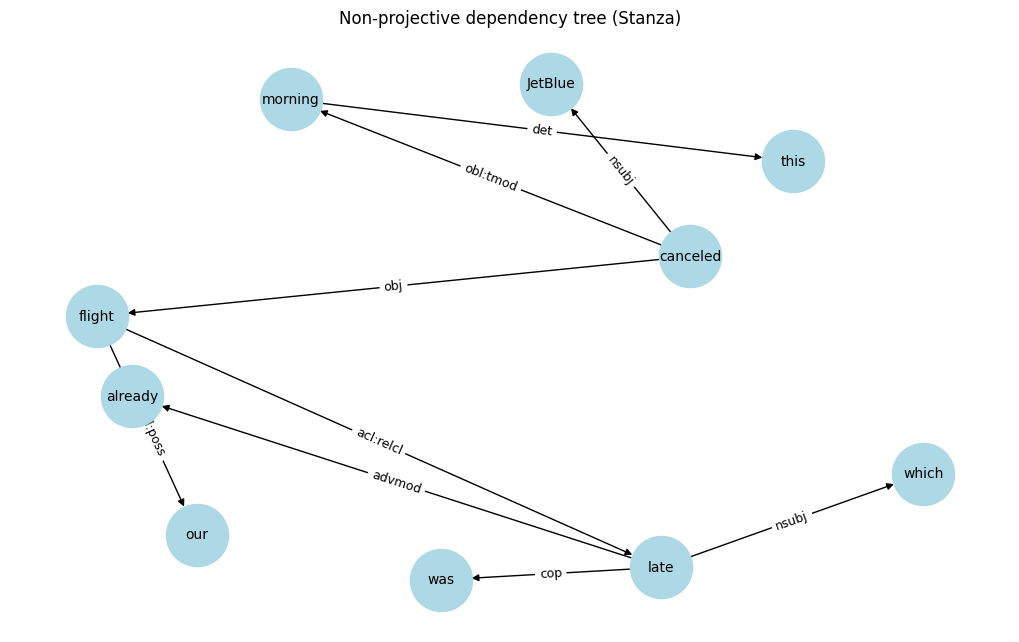

In [9]:
nonproj = "JetBlue canceled our flight this morning which was already late"

# Dùng Stanza (graph-based) để parse, có thể xử lý non-projective
doc_np = nlp_stanza(nonproj)
for sent in doc_np.sentences:
    words = [word.text for word in sent.words]
    heads = [word.head - 1 if word.head > 0 else -1 for word in sent.words]
    deprels = [word.deprel for word in sent.words]
    print("Words:", words)
    print("Heads:", heads)  # -1 là ROOT
    print("Deprels:", deprels)
    # Vẽ cây
    plot_dependency_tree(words, heads, deprels, title="Non-projective dependency tree (Stanza)")

Thử với spaCy (transition‑based)

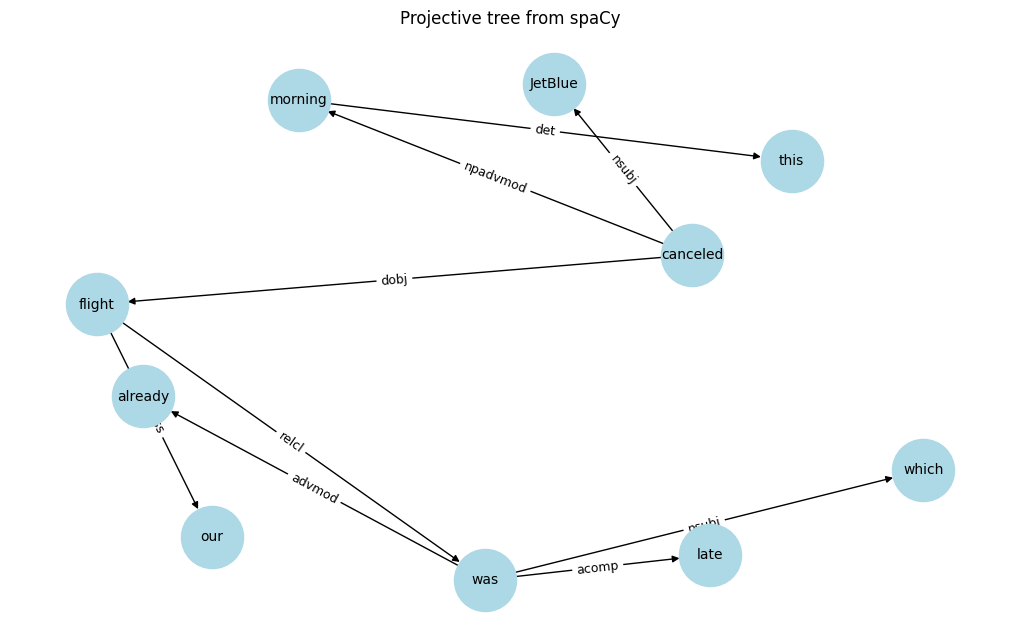

In [11]:
doc_np_spacy = nlp_spacy(nonproj)
words_spacy = [token.text for token in doc_np_spacy]
heads_spacy = []
deprels_spacy = []
for token in doc_np_spacy:
    if token.dep_ == "ROOT":
        heads_spacy.append(-1)
    else:
        heads_spacy.append(token.head.i)
    deprels_spacy.append(token.dep_)
plot_dependency_tree(words_spacy, heads_spacy, deprels_spacy, title="Projective tree from spaCy")